In [10]:
import pandas as pd
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("../data/cleaned/os_model_data.csv")

x_data = df["x"].values
y_data = df["y"].values

In [12]:
x0 = x_data[0]
y0 = y_data[0]

In [13]:
r1 = 0.07137313
r2 = 0.00149896
K1 = 1.14330309
K2 = 1.0
alpha = 0.10189428
beta = 0.0

In [14]:
def model(z, t, r1, r2, K1, K2, alpha, beta):
    
    x, y = z
    
    dx = r1 * x * (1 - x / K1) - alpha * x * y
    dy = r2 * y * (1 - y / K2) - beta * x * y
    
    return [dx, dy]

In [15]:
t = np.arange(len(x_data))

In [16]:
z0 = [x0, y0]

sol = odeint(
    model,
    z0,
    t,
    args=(r1, r2, K1, K2, alpha, beta)
)

x_model = sol[:, 0]
y_model = sol[:, 1]

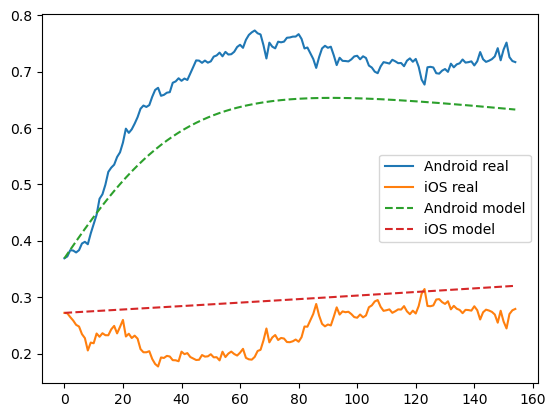

In [17]:
plt.plot(x_data, label="Android real")
plt.plot(y_data, label="iOS real")

plt.plot(x_model, "--", label="Android model")
plt.plot(y_model, "--", label="iOS model")

plt.legend()
plt.show()